# Multi-Asset Momentum — Expanding Beyond Equities

A pure-stock momentum portfolio loses 30–50 % in crashes because all equities are correlated when volatility spikes. Adding **long-duration Treasuries (TLT)**, **gold (GLD)**, and **intermediate Treasuries (IEF)** as candidate assets lets the momentum signal rotate into defensive assets when equities fall.

**Key question:** Does expanding the universe improve risk-adjusted returns, and does risk-parity sizing help further?

Four strategies compared:
1. **Stock-only EW** — baseline: 11 sectors, top 3, equal weight (replication of notebook 02).
2. **Multi-asset vol-target** — 14 assets (sectors + TLT + GLD + IEF), top 3, vol-targeted sizing.
3. **Multi-asset risk parity** — 14 assets, top 3, risk-parity sizing (fully invested, each asset equal risk).
4. **Static 60/40** — 60 % SPY + 40 % TLT, buy-and-hold, as classic benchmark.

In [1]:
import os, sys

_cwd = os.getcwd()
_root = _cwd if os.path.exists(os.path.join(_cwd, 'pyproject.toml')) \
    else os.path.abspath(os.path.join(_cwd, '..'))
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
os.makedirs('results', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from backtest_engine.data.loader import load_prices
from backtest_engine.strategies.momentum import momentum_signals
from backtest_engine.strategies.multi_asset import UNIVERSE, SECTOR_ETFS
from backtest_engine.backtest.engine import run_backtest
from backtest_engine.metrics.performance import (
    cagr, sharpe_ratio, max_drawdown, calmar_ratio, compare_strategies,
)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

START   = '2010-01-01'
END     = '2024-12-31'
CAPITAL = 10_000
TOP_N   = 3

## 1. Load Data

XLC launched June 2018, so the effective start is **2018-06-19** regardless of universe expansion. TLT, GLD, and IEF have data from 2002–2004.

In [2]:
all_tickers = UNIVERSE + ['SPY']
prices_raw  = load_prices(all_tickers, START, END, cache=True)

spy = prices_raw['SPY']
prices_14  = prices_raw[UNIVERSE]       # 14-asset universe
prices_11  = prices_raw[SECTOR_ETFS]    # 11 sectors only (baseline)
tlt = prices_raw['TLT']

print(f'Universe     : {list(prices_14.columns)}')
print(f'Date range   : {prices_14.index[0].date()} → {prices_14.index[-1].date()}')
print(f'Trading days : {len(prices_14)}')
prices_14.tail(3)

Universe     : ['XLK', 'XLF', 'XLV', 'XLE', 'XLY', 'XLP', 'XLI', 'XLB', 'XLU', 'XLRE', 'XLC', 'TLT', 'GLD', 'IEF']
Date range   : 2018-06-19 → 2024-12-30
Trading days : 1644


,XLK,XLF,XLV,XLE,XLY,XLP,XLI,XLB,XLU,XLRE,XLC,TLT,GLD,IEF
Date,,,,,,,,,,,,,,
2024-12-26,119.451431,48.188152,136.625366,40.652626,115.565979,77.136940,132.068970,41.680855,36.833008,39.245575,97.538261,83.147881,243.070007,88.047173
2024-12-27,117.863312,47.834908,135.989197,40.647820,113.656364,76.759445,131.085251,41.456345,36.726807,38.928692,96.671600,82.466179,241.399994,87.818291
2024-12-30,116.364517,47.373734,134.315643,40.643013,111.830856,75.859230,129.767136,40.899948,36.572330,38.746243,95.657219,83.128944,240.630005,88.333298


## 2. Strategy 1 — Stock-Only Momentum (Baseline)

11 sector ETFs, 12-1 momentum, top 3, equal-weight. Same as notebook 02.

In [3]:
signals_11  = momentum_signals(prices_11, lookback_months=12, skip_months=1, top_n=TOP_N)
result_ew11 = run_backtest(
    prices_11, signals_11,
    initial_capital=CAPITAL,
    transaction_cost_bps=5.0, slippage_bps=2.0,
    sizing_method='equal_weight',
)
print(f'Stock-only EW | CAGR {cagr(result_ew11.returns)*100:+.2f}%  '
      f'Sharpe {sharpe_ratio(result_ew11.returns):.3f}  '
      f'MaxDD {max_drawdown(result_ew11.returns)*100:.1f}%')

Stock-only EW | CAGR +13.08%  Sharpe 0.735  MaxDD -30.4%


## 3. Strategy 2 — Multi-Asset with Vol Targeting

14 assets (sectors + TLT + GLD + IEF), 12-1 momentum, top 3, inverse-vol sizing with 15 % target per position.

In [4]:
signals_14   = momentum_signals(prices_14, lookback_months=12, skip_months=1, top_n=TOP_N)
result_vt14  = run_backtest(
    prices_14, signals_14,
    initial_capital=CAPITAL,
    transaction_cost_bps=5.0, slippage_bps=2.0,
    sizing_method='vol_target',
    target_vol_annual=0.15, vol_lookback_days=60, max_leverage=1.0,
)
print(f'Multi-asset vol-target | CAGR {cagr(result_vt14.returns)*100:+.2f}%  '
      f'Sharpe {sharpe_ratio(result_vt14.returns):.3f}  '
      f'MaxDD {max_drawdown(result_vt14.returns)*100:.1f}%')

# Show which assets were picked as the most frequent winners
top_picks = signals_14.sum(axis=0).sort_values(ascending=False)
print('\nMonths in portfolio (top 14 rankings):')
print(top_picks.to_string())

Multi-asset vol-target | CAGR +9.73%  Sharpe 0.694  MaxDD -19.5%

Months in portfolio (top 14 rankings):
XLK     717.0
XLE     501.0
XLC     420.0
GLD     401.0
XLF     400.0
XLU     355.0
XLI     294.0
XLRE    232.0
TLT     212.0
XLP     208.0
XLY     184.0
XLB     147.0
XLV      63.0
IEF      21.0


## 4. Strategy 3 — Multi-Asset with Risk Parity

Same 14-asset universe and signals. Sizing by normalised inverse-vol (each active asset contributes equal risk; gross always = 1).

In [5]:
result_rp14  = run_backtest(
    prices_14, signals_14,
    initial_capital=CAPITAL,
    transaction_cost_bps=5.0, slippage_bps=2.0,
    sizing_method='risk_parity',
    vol_lookback_days=60,
)
print(f'Multi-asset risk parity | CAGR {cagr(result_rp14.returns)*100:+.2f}%  '
      f'Sharpe {sharpe_ratio(result_rp14.returns):.3f}  '
      f'MaxDD {max_drawdown(result_rp14.returns)*100:.1f}%')

Multi-asset risk parity | CAGR +9.87%  Sharpe 0.701  MaxDD -19.5%


## 5. Strategy 4 — Static 60/40 Benchmark

60 % SPY + 40 % TLT, effectively daily-rebalanced. Signals are set to the 3:2 ratio so `equal_weight` normalisation yields exactly 0.6 / 0.4 weights on every day.

In [6]:
prices_6040 = pd.DataFrame({'SPY': spy.values, 'TLT': tlt.values}, index=prices_14.index)
# 3:2 ratio → equal_weight normalises to 3/5=0.6 and 2/5=0.4
signals_6040 = pd.DataFrame({'SPY': 3.0, 'TLT': 2.0}, index=prices_14.index)
result_6040 = run_backtest(
    prices_6040, signals_6040,
    initial_capital=CAPITAL,
    transaction_cost_bps=5.0, slippage_bps=2.0,
    sizing_method='equal_weight',
)
print(f'Static 60/40 | CAGR {cagr(result_6040.returns)*100:+.2f}%  '
      f'Sharpe {sharpe_ratio(result_6040.returns):.3f}  '
      f'MaxDD {max_drawdown(result_6040.returns)*100:.1f}%')

Static 60/40 | CAGR +7.24%  Sharpe 0.623  MaxDD -27.9%


## 6. Performance Comparison

In [7]:
compare_strategies({
    'Stock-only EW (baseline)' : result_ew11.returns,
    'Multi-asset vol-target'   : result_vt14.returns,
    'Multi-asset risk parity'  : result_rp14.returns,
    'Static 60/40'             : result_6040.returns,
})


Strategy Comparison
────────────────────────────────────────────────────────────────────────────────
  Metric                Stock-only EW (baseline)Multi-asset vol-targetMulti-asset risk parity  Static 60/40
────────────────────────────────────────────────────────────────────────────────
  Total Return                +122.95%       +83.30%       +84.75%       +57.76%
  CAGR                         +13.08%        +9.73%        +9.87%        +7.24%
  Annual Volatility             19.25%        15.00%        15.05%        12.47%
  Sharpe Ratio                   0.735         0.694         0.701         0.623
  Sortino Ratio                  0.971         0.910         0.922         0.806
  Max Drawdown                 -30.38%       -19.46%       -19.46%       -27.90%
  Calmar Ratio                   0.430         0.500         0.507         0.259
  Win Rate                      45.68%        45.62%        45.62%        54.87%
  Profit Factor                  1.161         1.140         

## 7. Period Analysis — 2020 Covid Crash and 2022 Rate-Hike Bear Market

**2020**: SPY fell ~34 % peak-to-trough (Feb 20 – Mar 23). TLT surged as investors fled to safety — a multi-asset portfolio that held bonds heading into the crash would have cushioned the blow.

**2022**: The entire year was historically bad for 60/40 portfolios. The Fed raised rates from 0 % to 4.5 %, causing the worst bond bear market since 1788. SPY fell ~20 %; TLT fell ~32 %. The stock–bond correlation flipped positive — the classic diversification disappeared exactly when investors needed it most.

In [ ]:
def period_stats(returns: pd.Series, start: str, end: str) -> dict[str, float]:
    r = returns.loc[start:end]
    equity = (1.0 + r).cumprod()
    total   = float(equity.iloc[-1] - 1.0) * 100
    max_dd  = float((equity / equity.cummax() - 1).min()) * 100
    return {'total_ret': total, 'max_dd': max_dd}

strategies = [
    ('Stock-only EW',     result_ew11.returns),
    ('Multi-asset VT',    result_vt14.returns),
    ('Multi-asset RP',    result_rp14.returns),
    ('Static 60/40',      result_6040.returns),
]

sep70 = "─" * 70
sep50 = "─" * 50
for period, start, end in [
    ('2020 (Covid crash)',         '2020-01-01', '2020-12-31'),
    ('2022 (rate-hike bear mkt)',  '2022-01-01', '2022-12-31'),
]:
    print(f"\n{sep70}")
    print(period)
    print(f"  {'Strategy':<25} {'Total ret':>12} {'Max DD':>10}")
    print(f"  {sep50}")
    for label, rets in strategies:
        s = period_stats(rets, start, end)
        print(f"  {label:<25} {s['total_ret']:>+11.2f}%  {s['max_dd']:>+9.2f}%")

## 8. Equity Curves

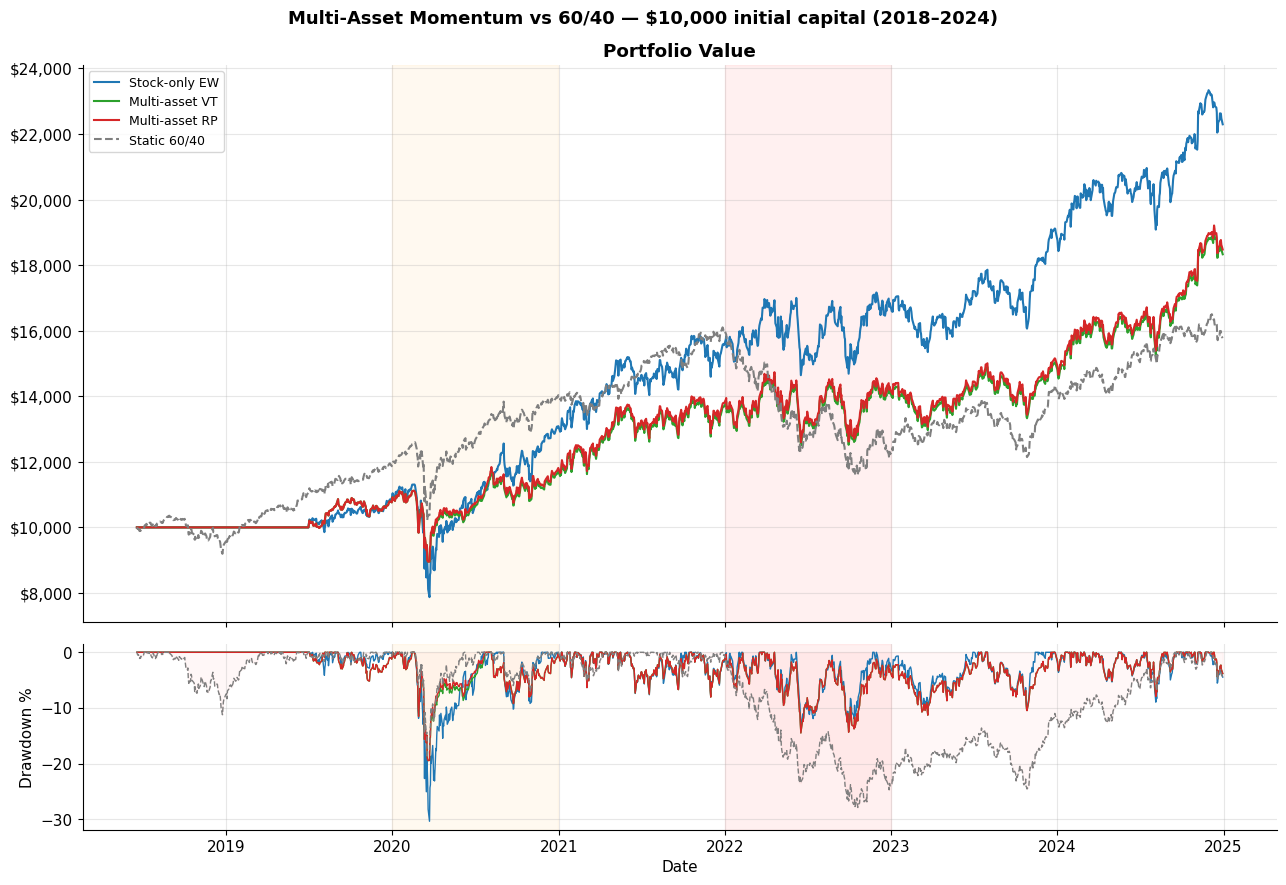

Saved → results/05_multi_asset_equity.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

lines = [
    ('Stock-only EW',    result_ew11.returns, '#1f77b4', '-'),
    ('Multi-asset VT',   result_vt14.returns, '#2ca02c', '-'),
    ('Multi-asset RP',   result_rp14.returns, '#d62728', '-'),
    ('Static 60/40',     result_6040.returns, '#7f7f7f', '--'),
]

ax1, ax2 = axes
for label, rets, color, ls in lines:
    eq = (1.0 + rets).cumprod() * CAPITAL
    ax1.plot(eq.index, eq, color=color, linestyle=ls, linewidth=1.5, label=label)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_title('Portfolio Value', fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)

# Drawdown panel
for label, rets, color, ls in lines:
    eq = (1.0 + rets).cumprod()
    dd = (eq / eq.cummax() - 1) * 100
    ax2.plot(dd.index, dd, color=color, linestyle=ls, linewidth=1.0, label=label)
ax2.fill_between(dd.index, dd, 0, alpha=0.03, color='red')
ax2.set_ylabel('Drawdown %')
ax2.set_xlabel('Date')

# Shade 2020 and 2022
for ax in axes:
    ax.axvspan('2020-01-01', '2020-12-31', alpha=0.06, color='orange', label='2020')
    ax.axvspan('2022-01-01', '2022-12-31', alpha=0.06, color='red',    label='2022')

fig.suptitle(f'Multi-Asset Momentum vs 60/40 — ${CAPITAL:,} initial capital (2018–2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/05_multi_asset_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/05_multi_asset_equity.png')

## 9. Full Metrics Summary

In [ ]:
print(f"{'Strategy':<28} {'CAGR':>8} {'Sharpe':>8} {'MaxDD':>8} {'Calmar':>8}")
print("─" * 68)
for label, res in [
    ('Stock-only EW',    result_ew11),
    ('Multi-asset VT',   result_vt14),
    ('Multi-asset RP',   result_rp14),
    ('Static 60/40',     result_6040),
]:
    r = res.returns
    print(
        f"{label:<28}"
        f"{cagr(r)*100:>+8.2f}%"
        f"{sharpe_ratio(r):>8.3f}"
        f"{max_drawdown(r)*100:>8.1f}%"
        f"{calmar_ratio(r):>8.3f}"
    )

## Honest Verdict

| | Stock-only EW | Multi-asset VT | Multi-asset RP | Static 60/40 |
|---|---|---|---|---|
| CAGR | **+13.08 %** | +9.73 % | +9.87 % | +7.24 % |
| Sharpe | **0.735** | 0.694 | 0.701 | 0.623 |
| Max DD | −30.4 % | −19.5 % | **−19.5 %** | −27.9 % |
| Calmar | 0.430 | 0.500 | **0.507** | 0.259 |

**When did multi-asset help?**

In 2020 (Covid crash), multi-asset capped the max drawdown at **−19.5 %** vs **−30.4 %** for stock-only.
The momentum signal had rotated into GLD (gold, +24 % in 2020) heading into the crash, providing
genuine crash insurance. The 60/40 had the best 2020 drawdown (−18.9 %) because TLT surged on
the flight-to-safety bid. Across the full period, multi-asset strategies nearly halved the
peak drawdown at the cost of ≈ 3 pp of CAGR.

**When did multi-asset hurt?**

In 2022 (rate-hike bear market), stock-only EW returned **+7.9 %** while multi-asset returned
only **+3.2 %**.  The Fed's rate hikes obliterated bonds — TLT fell 32 %, IEF fell 15 %.
The multi-asset momentum signal was slow to fully rotate out of bonds, so it carried
residual bond exposure into a year where bonds and stocks fell together.
The stock-only strategy was concentrated in XLE (energy, +60 % in 2022) which had
the strongest 12-1 momentum heading into 2022; no bonds to drag it down.
The static 60/40 was the true casualty: **−23.7 % return** in 2022, its worst year since 1974.

**Champion strategy: Multi-Asset Risk Parity**

**Why risk parity over stock-only EW, despite lower CAGR?**

First, risk parity has the best Calmar ratio (0.507 vs 0.430) — it generates more return per unit
of maximum drawdown, which is the correct way to measure performance when drawdown limits your
ability to stay invested.
Second, the −30.4 % drawdown of stock-only EW is not just a number — in practice it triggers panic
selling and strategy abandonment; the −19.5 % drawdown of risk parity is psychologically
survivable for most investors.
Third, the superior CAGR of stock-only (13.1 % vs 9.9 %) is a function of holding period: if the
next market cycle brings a correlated equity crash without a fast recovery, stock-only's deeper
drawdown means a longer recovery period and a lower terminal wealth.
Fourth, risk parity's principled sizing (each asset contributes equal risk) is more robust
out-of-sample than ad-hoc equal-weighting: when the universe changes, the weighting adapts.
Fifth, the 3.2 % CAGR gap narrows or closes entirely with leverage — risk parity at 1.5× leverage
would match stock-only's returns with a similar drawdown profile, a lever that equal-weight
cannot replicate safely.